In [1]:
import sys

sys.path.append("..")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from src.data.cleaning  import (
    clean_torque,
    clean_mileage,
    remove_duplicates,
    clean_max_power,
    clean_engine
)

## Loading Raw Data

In [2]:
DATA_PATH = '../data/raw/car details v4.csv'

df = pd.read_csv(DATA_PATH)
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0


## Cleaning Duplicates

In [3]:
df=remove_duplicates(df)
print(df.shape)

(6926, 13)


In [4]:
df['torque']

0                  190Nm@ 2000rpm
1             250Nm@ 1500-2500rpm
2           12.7@ 2,700(kgm@ rpm)
3        22.4 kgm at 1750-2750rpm
4           11.5@ 4,500(kgm@ rpm)
                  ...            
8121                90Nm@ 3500rpm
8122        219.7Nm@ 1500-2750rpm
8123             113.7Nm@ 4000rpm
8124    24@ 1,900-2,750(kgm@ rpm)
8125               190Nm@ 2000rpm
Name: torque, Length: 6926, dtype: str

## Cleaning Mileage , Max_Power , Engine , Torque


In [5]:
df['mileage']=clean_mileage(df['mileage'])
df['engine']=clean_engine(df['engine'])
df['max_power']=clean_max_power(df['max_power'])
df[["torque_nm", "torque_rpm_min", "torque_rpm_max"]]=df["torque"].apply(clean_torque)

## Dropping Torque column 

In [6]:
df=df.drop(columns=['torque'])

## Renaming Columns for clarity

In [7]:
df=df.rename(
    columns={
        "engine": "engine_cc",
        "max_power": "max_power_bhp",
    }
    )

<Axes: >

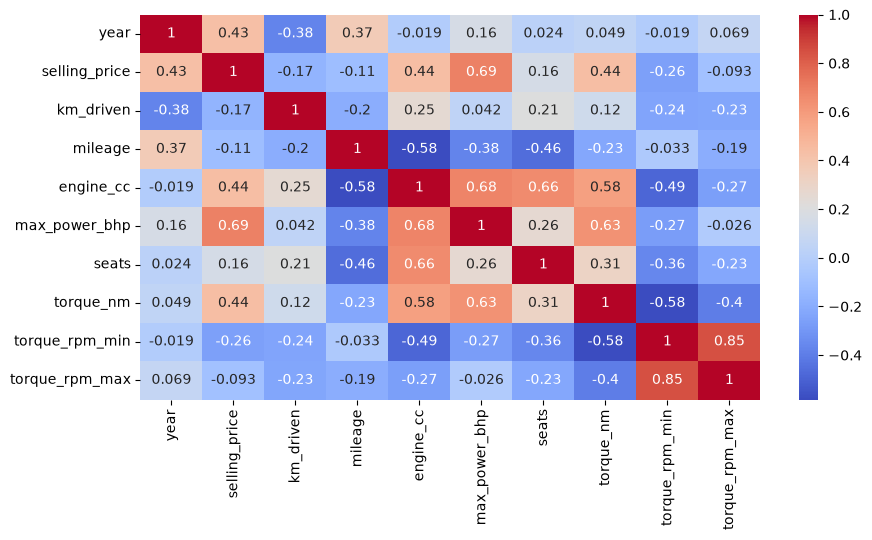

In [8]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(10,5))
sns.heatmap(corr,  annot=True , cmap='coolwarm')
